In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_excel("C:/Users/2024/Downloads/Retail_Sales_Task_Dataset.xlsx")

In [5]:
df.head()

,OrderID,OrderDate,ShipDate,CustomerID,CustomerName,City,Region,Category,SubCategory,Product,Salesperson,Quantity,UnitPrice,Discount,Sales,Cost,Profit,PaymentMethod
0,O0001,2025-06-16,2025-06-17,C004,Customer 33,Alexandria,West,Electronics,Phone,Phone Model 2,Omar,2,1500,0.00,3000.0,2033.97,966.03,Cash
1,O0002,2025-03-03,2025-03-04,C015,Customer 4,Tanta,North,Accessories,Mouse,Mouse Model 5,Nada,7,120,0.20,672.0,498.40,173.60,Card
2,O0003,2025-05-23,2025-05-25,C020,Customer 12,Cairo,North,Electronics,Laptop,Laptop Model 1,Nada,5,900,0.05,4275.0,3326.58,948.42,Wallet
3,O0004,2025-01-25,2025-01-30,C032,Customer 35,Asyut,South,Electronics,Phone,Phone Model 4,Mona,2,1500,0.00,3000.0,2299.96,700.04,Card
4,O0005,2025-03-18,2025-03-20,C020,Customer 34,Mansoura,East,Accessories,Keyboard,Keyboard Model 4,Mona,3,2200,0.05,6270.0,3819.09,2450.91,Wallet


In [6]:
df.shape

(80, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        80 non-null     object 
 1   OrderDate      80 non-null     object 
 2   ShipDate       80 non-null     object 
 3   CustomerID     80 non-null     object 
 4   CustomerName   80 non-null     object 
 5   City           80 non-null     object 
 6   Region         80 non-null     object 
 7   Category       80 non-null     object 
 8   SubCategory    80 non-null     object 
 9   Product        80 non-null     object 
 10  Salesperson    80 non-null     object 
 11  Quantity       80 non-null     int64  
 12  UnitPrice      80 non-null     int64  
 13  Discount       80 non-null     float64
 14  Sales          80 non-null     float64
 15  Cost           80 non-null     float64
 16  Profit         80 non-null     float64
 17  PaymentMethod  80 non-null     object 
dtypes: float64(4

In [8]:
df.describe()

,Quantity,UnitPrice,Discount,Sales,Cost,Profit
count,80.000000,80.000000,80.00000,80.000000,80.000000,80.000000
mean,4.662500,915.000000,0.09375,3792.437500,3059.374625,733.062875
std,2.288904,732.846021,0.06861,3822.368623,3087.905779,1007.517880
min,1.000000,120.000000,0.00000,96.000000,78.660000,-1073.420000
25%,3.000000,250.000000,0.05000,860.500000,750.450000,75.680000
50%,5.000000,900.000000,0.10000,2250.000000,1800.235000,396.835000
75%,7.000000,1500.000000,0.15000,5617.500000,4719.562500,971.215000
max,8.000000,2200.000000,0.20000,17600.000000,13583.820000,5552.440000


In [9]:
#Data Cleaning missing values
df.isnull().sum()

OrderID          0
OrderDate        0
ShipDate         0
CustomerID       0
CustomerName     0
City             0
Region           0
Category         0
SubCategory      0
Product          0
Salesperson      0
Quantity         0
UnitPrice        0
Discount         0
Sales            0
Cost             0
Profit           0
PaymentMethod    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [12]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['ShipDate'] = pd.to_datetime(df['ShipDate'])


In [14]:
df.dtypes

OrderID                  object
OrderDate        datetime64[ns]
ShipDate         datetime64[ns]
CustomerID               object
CustomerName             object
City                     object
Region                   object
Category                 object
SubCategory              object
Product                  object
Salesperson              object
Quantity                  int64
UnitPrice                 int64
Discount                float64
Sales                   float64
Cost                    float64
Profit                  float64
PaymentMethod            object
dtype: object

In [15]:
df['ShippingDays'] = (df['ShipDate'] - df['OrderDate']).dt.days

In [17]:
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['MonthName'] = df['OrderDate'].dt.month_name()

In [18]:
df['ProfitMargin'] = (df['Profit'] / df['Sales']) * 100

In [19]:
total_sales = df['Sales'].sum()
total_sales

303395.0

In [20]:
total_profit = df['Profit'].sum()
total_profit

58645.03

In [21]:
total_cost = df['Cost'].sum()
total_cost

244749.97

In [22]:
total_orders = df['OrderID'].nunique()
total_orders

80

In [23]:
average_order_value = df['Sales'].mean()
average_order_value

3792.4375

In [24]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

Category
Electronics    146242.0
Office         102960.0
Accessories     54193.0
Name: Sales, dtype: float64

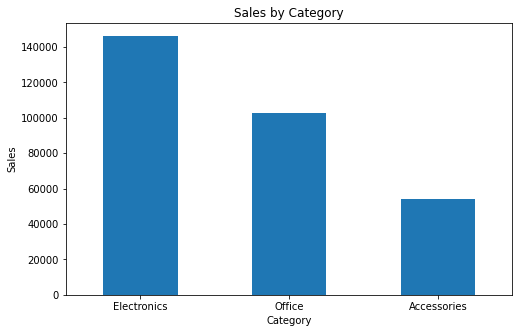

In [25]:
category_sales.plot(kind='bar', figsize=(8,5))

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

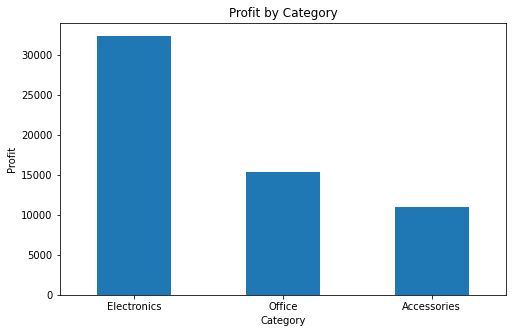

In [26]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

category_profit.plot(kind='bar', figsize=(8,5))

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

In [27]:
top_products = (
    df.groupby('Product')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product
Laptop Model 5     30745.0
Printer Model 1    26015.0
Tablet Model 1     23490.0
Laptop Model 4     18430.0
Phone Model 5      17600.0
Chair Model 1      16433.0
Printer Model 4    13030.0
Laptop Model 3     11957.5
Monitor Model 1    11325.0
Printer Model 3    11281.0
Name: Sales, dtype: float64

In [28]:
bottom_products = (
    df.groupby('Product')['Sales']
    .sum()
    .sort_values()
    .head(10)
)

bottom_products

Product
Monitor Model 3      102.0
Keyboard Model 5     450.0
Mouse Model 5        672.0
Mouse Model 2       1158.0
Tablet Model 3      1314.0
Headset Model 1     1575.0
Chair Model 5       1800.0
Monitor Model 5     2050.0
Keyboard Model 2    2106.0
Tablet Model 5      2342.0
Name: Sales, dtype: float64

In [29]:
region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
North    150701.5
South     80571.0
East      36218.5
West      35904.0
Name: Sales, dtype: float64

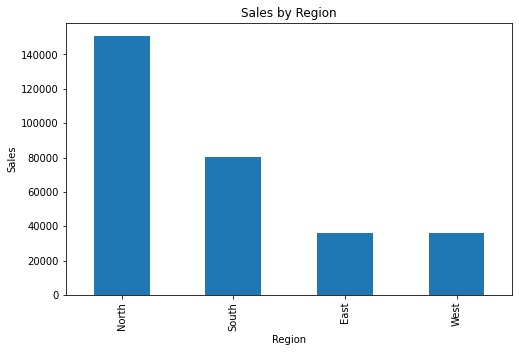

In [30]:
region_sales.plot(kind='bar', figsize=(8,5))

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

In [31]:
top_customers = (
    df.groupby(['CustomerID', 'CustomerName'])['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID  CustomerName
C034        Customer 19     17600.0
C010        Customer 26     15400.0
C018        Customer 22     12320.0
C021        Customer 34     12000.0
C026        Customer 34     10200.0
C034        Customer 33      9975.0
C009        Customer 1       9900.0
C028        Customer 7       9600.0
            Customer 18      9450.0
C013        Customer 23      8925.0
Name: Sales, dtype: float64

In [32]:
salesperson_performance = (
    df.groupby('Salesperson')
    .agg({
        'Sales': 'sum',
        'Profit': 'sum',
        'OrderID': 'nunique'
    })
    .sort_values('Sales', ascending=False)
)

salesperson_performance

,Sales,Profit,OrderID
Salesperson,,,
Youssef,64272.0,15723.53,18
Omar,62901.5,14910.59,17
Mona,57563.0,9948.21,13
Ali,40942.0,5207.54,13
Nada,38921.0,7008.10,12
Sara,38795.5,5847.06,7


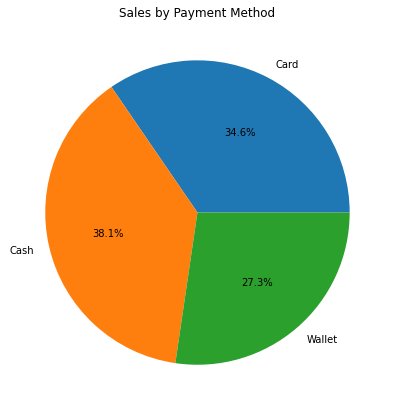

In [33]:
payment_sales = df.groupby('PaymentMethod')['Sales'].sum()

payment_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title('Sales by Payment Method')
plt.ylabel('')
plt.show()

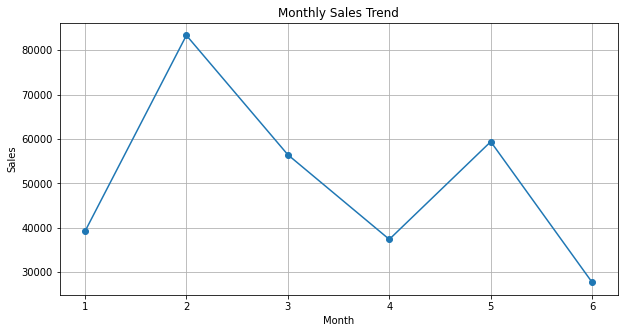

In [34]:
monthly_sales = (
    df.groupby('Month')['Sales']
    .sum()
)

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid()
plt.show()

In [35]:
df[['Discount', 'Sales', 'Profit']].corr()

,Discount,Sales,Profit
Discount,1.000000,-0.095755,-0.281786
Sales,-0.095755,1.000000,0.790738
Profit,-0.281786,0.790738,1.000000


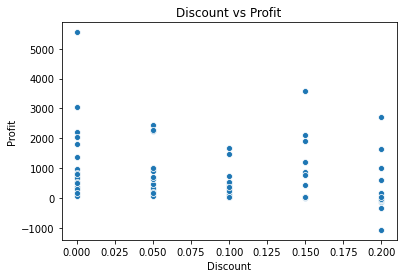

In [36]:
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title('Discount vs Profit')
plt.show()

In [37]:
df['ShippingDays'].describe()

count    80.000000
mean      3.550000
std       1.668016
min       1.000000
25%       2.000000
50%       4.000000
75%       5.000000
max       6.000000
Name: ShippingDays, dtype: float64

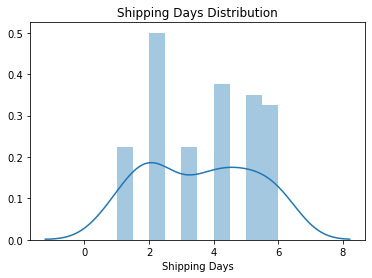

In [42]:
sns.distplot(df['ShippingDays'], bins=10)

plt.title('Shipping Days Distribution')
plt.xlabel('Shipping Days')
plt.show()

In [43]:
df.groupby('Region')['ShippingDays'].mean().sort_values(ascending=False)

Region
East     4.166667
South    3.666667
West     3.375000
North    3.305556
Name: ShippingDays, dtype: float64